# Financial Analysis & Valuation Modeling: The Coca-Cola Company (FY 2009 – FY 2018)

## 1. Environment Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for publication-quality charts
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 300

# File path
file_path = "Cola.xlsx"

# Load spreadsheet
raw_df = pd.read_excel(file_path)
print("File successfully loaded. Shape:", raw_df.shape)

File successfully loaded. Shape: (103, 12)


## 2. Statement Extraction & Data Cleaning

2.1 Section Segmentation


In [2]:
# Identify section start indices
pnl_start = raw_df[raw_df.iloc[:, 0] == 'Profit & Loss statement'].index[0]
bs_start = raw_df[raw_df.iloc[:, 0] == 'Balance Sheet'].index[0]
cf_start = raw_df[raw_df.iloc[:, 0] == 'Cash Flow statement'].index[0]

def parse_statement(df, start_idx, end_idx):
    """Parses and formats a financial statement block from raw Excel rows."""
    sub_df = df.iloc[start_idx:end_idx].copy()
    headers = sub_df.iloc[1].values[2:]
    sub_df = sub_df.iloc[2:]
    sub_df.columns = ['Category', 'Line Item'] + list(headers)
    sub_df = sub_df.drop(columns=['Category']).dropna(subset=['Line Item'])
    sub_df['Line Item'] = sub_df['Line Item'].str.strip()
    sub_df = sub_df.drop_duplicates(subset=['Line Item'], keep='first').set_index('Line Item')
    
    # Cast year columns to float
    year_cols = [c for c in sub_df.columns if 'FY' in str(c)]
    sub_df[year_cols] = sub_df[year_cols].apply(pd.to_numeric, errors='coerce')
    return sub_df

# Extract individual statements
pnl_df = parse_statement(raw_df, pnl_start, bs_start)
bs_df = parse_statement(raw_df, bs_start, cf_start)
cf_df = parse_statement(raw_df, cf_start, len(raw_df))

years = [c for c in pnl_df.columns if 'FY' in str(c)]
print(f"Extracted financial statements successfully across {len(years)} fiscal years ({years[0]} - {years[-1]}).")

Extracted financial statements successfully across 10 fiscal years (FY '09 - FY '18).


## 3. Financial Ratio & Metric Computation

In [3]:
# Extract primary line items
revenue = pnl_df.loc['NET OPERATING REVENUES', years]
gross_profit = pnl_df.loc['Gross Profit', years]
op_income = pnl_df.loc['Operating Income', years]
net_income = pnl_df.loc['NET INCOME ATTRIBUTABLE TO SHAREOWNERS OF THE COCA-COLA COMPANY', years]

# Calculate Margins (%)
gross_margin = (gross_profit / revenue) * 100
op_margin = (op_income / revenue) * 100
net_margin = (net_income / revenue) * 100

# Balance Sheet Metrics
current_assets = bs_df.loc['Total current assets', years]
current_liab = bs_df.loc['Total current liabilities', years]
current_ratio = current_assets / current_liab

total_equity = bs_df.loc['Total equity', years]
long_term_debt = bs_df.loc['Long-term debt', years]
short_term_debt = bs_df.loc['Loans and notes payable', years]
total_debt = long_term_debt + short_term_debt
debt_to_equity = total_debt / total_equity

# Cash Flow Metrics
ocf = cf_df.loc['Net cash provided by operating activities', years]
capex = np.abs(cf_df.loc['Purchases of property, plant and equipment', years])
free_cash_flow = ocf - capex

dividends = np.abs(cf_df.loc['Dividends', years])
buybacks = np.abs(cf_df.loc['Purchases of stock for treasury', years])

# Construct consolidated summary dataframe
financial_summary = pd.DataFrame({
    'Revenue ($M)': revenue,
    'Gross Profit ($M)': gross_profit,
    'Operating Income ($M)': op_income,
    'Net Income ($M)': net_income,
    'Gross Margin (%)': gross_margin.round(2),
    'Operating Margin (%)': op_margin.round(2),
    'Net Margin (%)': net_margin.round(2),
    'Current Ratio': current_ratio.round(2),
    'Total Debt ($M)': total_debt,
    'Debt-to-Equity': debt_to_equity.round(2),
    'Operating Cash Flow ($M)': ocf,
    'CapEx ($M)': capex,
    'Free Cash Flow ($M)': free_cash_flow,
    'Dividends Paid ($M)': dividends,
    'Share Buybacks ($M)': buybacks
})

financial_summary


,Revenue ($M),Gross Profit ($M),Operating Income ($M),Net Income ($M),Gross Margin (%),Operating Margin (%),Net Margin (%),Current Ratio,Total Debt ($M),Debt-to-Equity,Operating Cash Flow ($M),CapEx ($M),Free Cash Flow ($M),Dividends Paid ($M),Share Buybacks ($M)
FY '09,30990.0,19902.0,8231.0,6824.0,64.22,26.56,22.02,1.28,11808.0,0.47,8186.0,1993.0,6193.0,3800.0,1518.0
FY '10,35119.0,22426.0,8413.0,11787.0,63.86,23.96,33.56,1.17,22141.0,0.71,9532.0,2215.0,7317.0,4068.0,2961.0
FY '11,46542.0,28327.0,10173.0,8584.0,60.86,21.86,18.44,1.05,26527.0,0.83,9474.0,2920.0,6554.0,4300.0,4513.0
FY '12,48017.0,28964.0,10779.0,9019.0,60.32,22.45,18.78,1.09,31033.0,0.94,10645.0,2780.0,7865.0,4595.0,4559.0
FY '13,46854.0,28433.0,10228.0,8584.0,60.68,21.83,18.32,1.13,36055.0,1.08,10542.0,2550.0,7992.0,4969.0,4832.0
FY '14,45998.0,28109.0,9708.0,7098.0,61.11,21.11,15.43,1.02,38193.0,1.25,10615.0,2406.0,8209.0,5350.0,4162.0
FY '15,44294.0,26812.0,8728.0,7351.0,60.53,19.70,16.60,1.24,41440.0,1.61,10528.0,2553.0,7975.0,5741.0,3564.0
FY '16,41863.0,25398.0,8626.0,6527.0,60.67,20.61,15.59,1.28,42182.0,1.82,8796.0,2262.0,6534.0,6043.0,3681.0
FY '17,35410.0,22155.0,7599.0,1248.0,62.57,21.46,3.52,1.34,44387.0,2.34,6930.0,1675.0,5255.0,6320.0,3682.0
FY '18,31856.0,20086.0,8700.0,6434.0,63.05,27.31,20.20,1.05,38558.0,2.02,7320.0,1347.0,5973.0,6644.0,1912.0


## 4. Visualizations & Trend Analysis

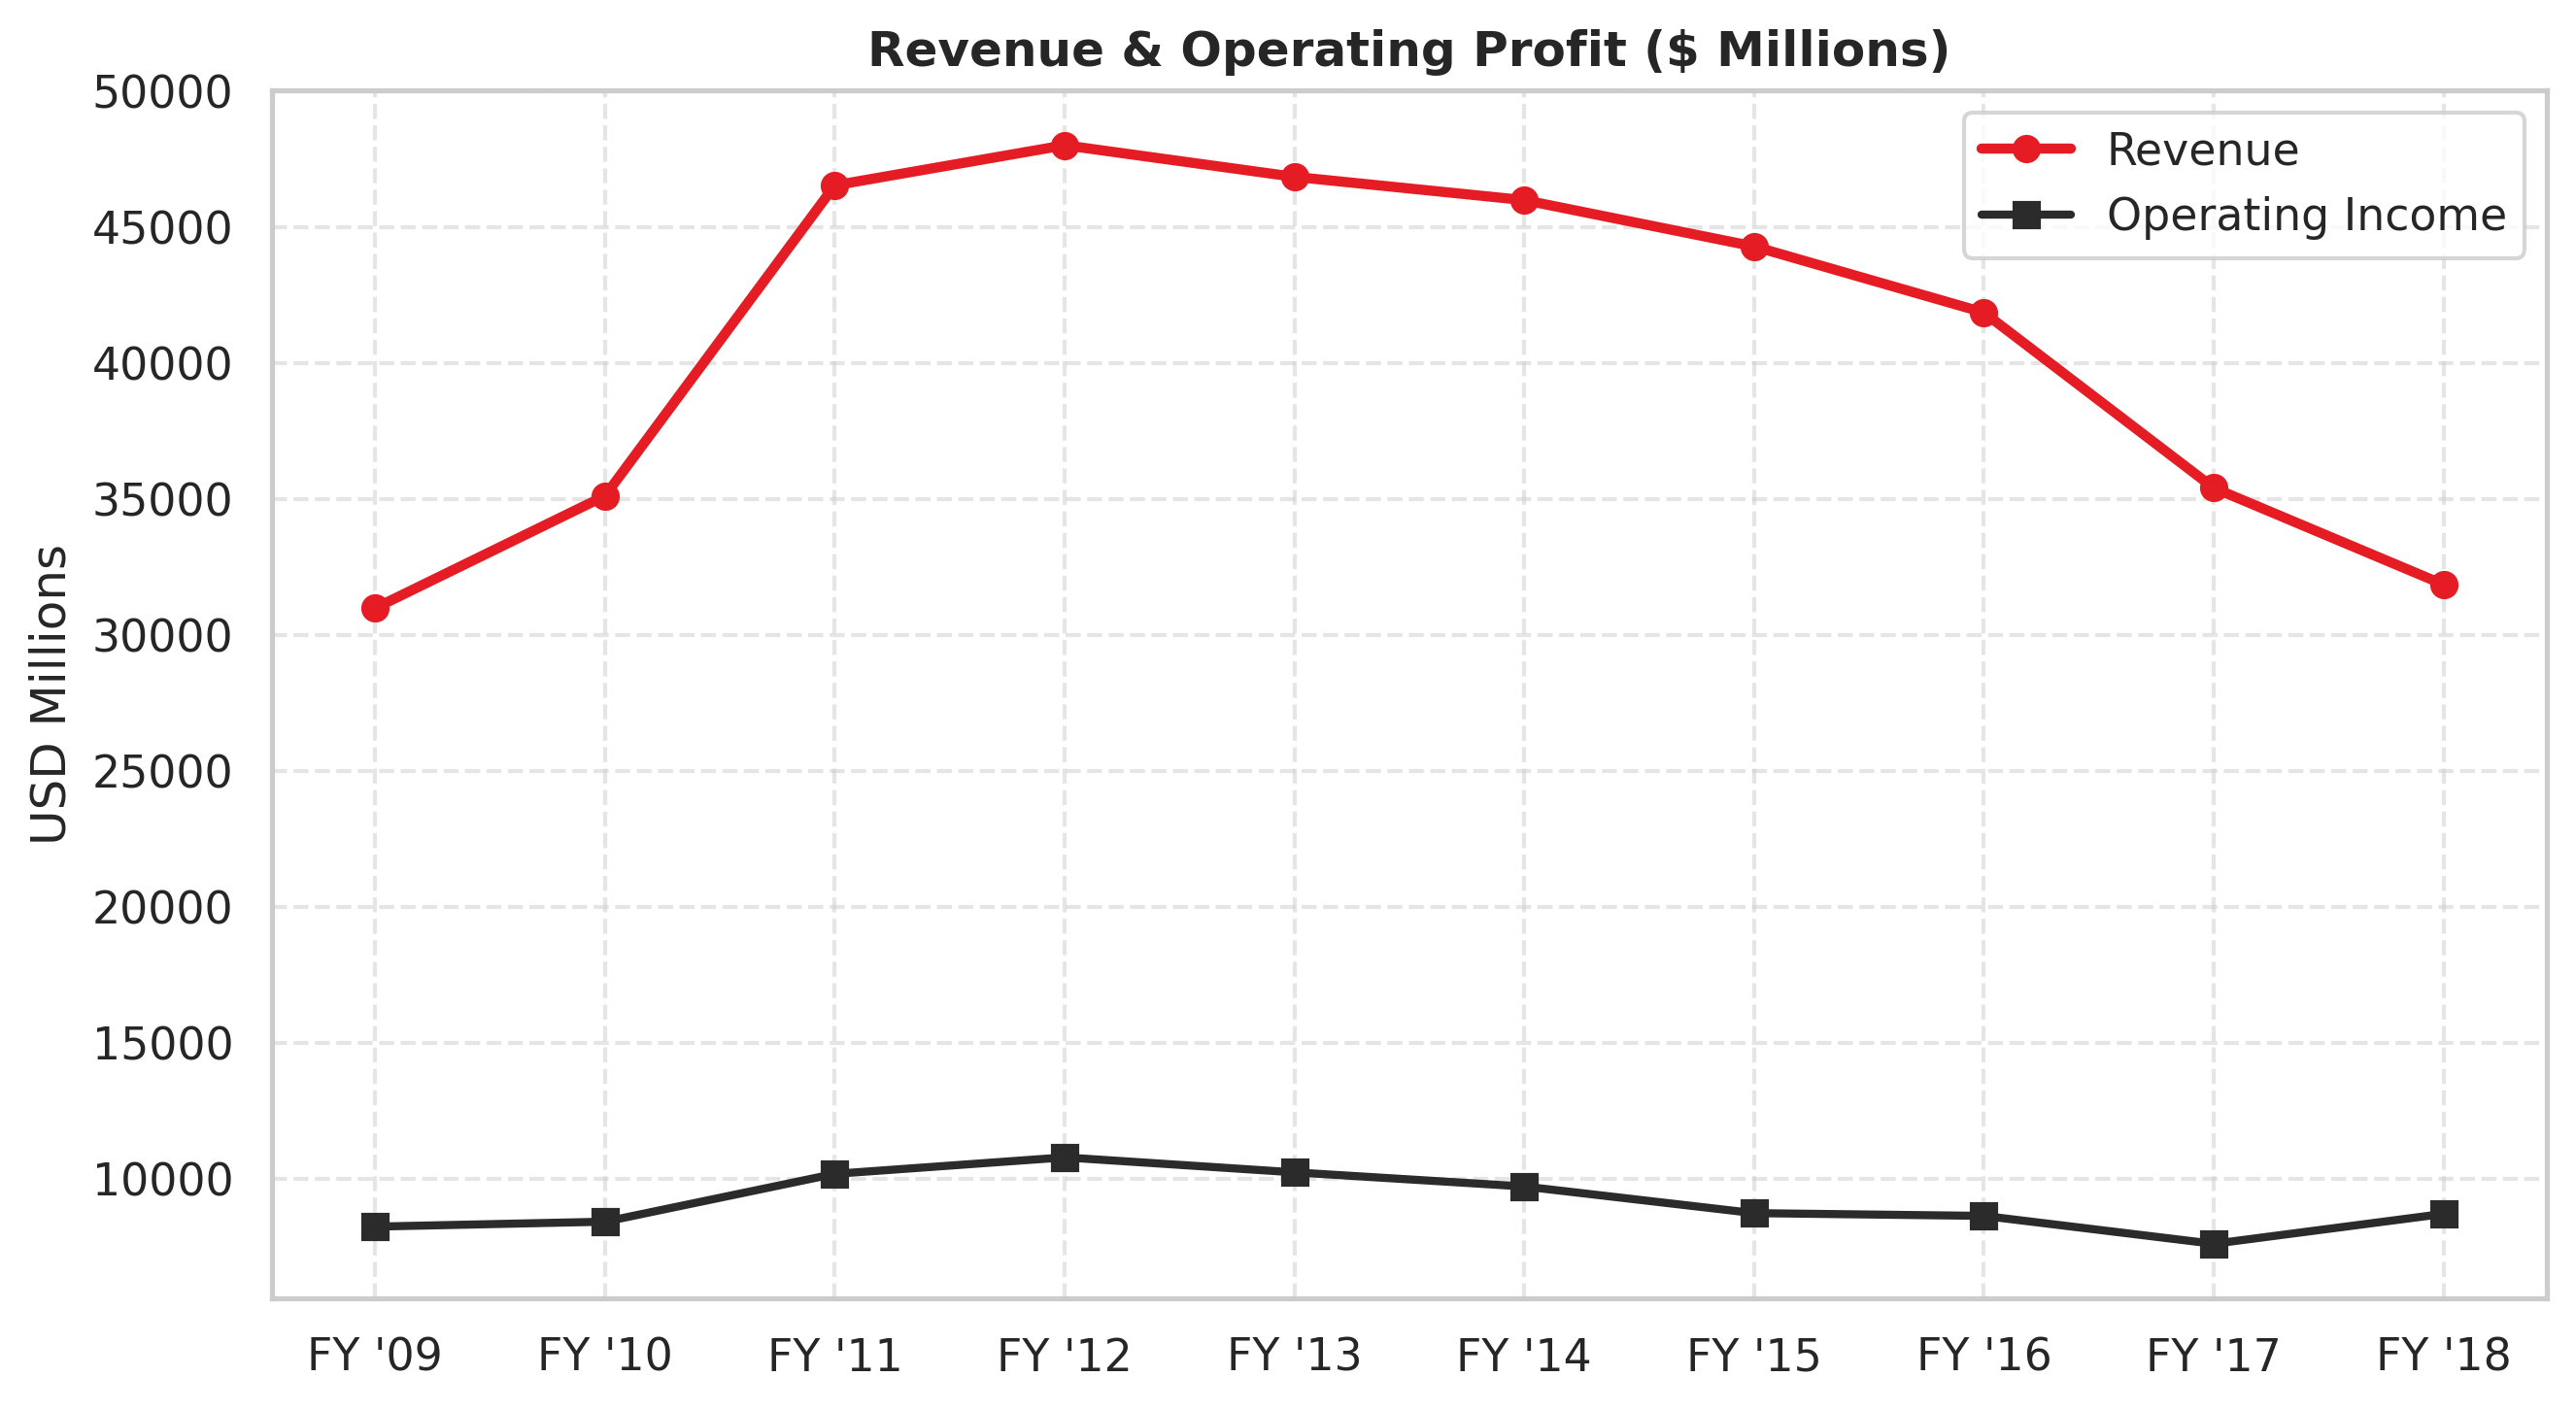

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(years, financial_summary['Revenue ($M)'], marker='o', color='#E61C24', linewidth=2.5, label='Revenue')
plt.plot(years, financial_summary['Operating Income ($M)'], marker='s', color='#2B2B2B', linewidth=2, label='Operating Income')

plt.title('Revenue & Operating Profit ($ Millions)', fontsize=12, fontweight='bold')
plt.ylabel('USD Millions')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


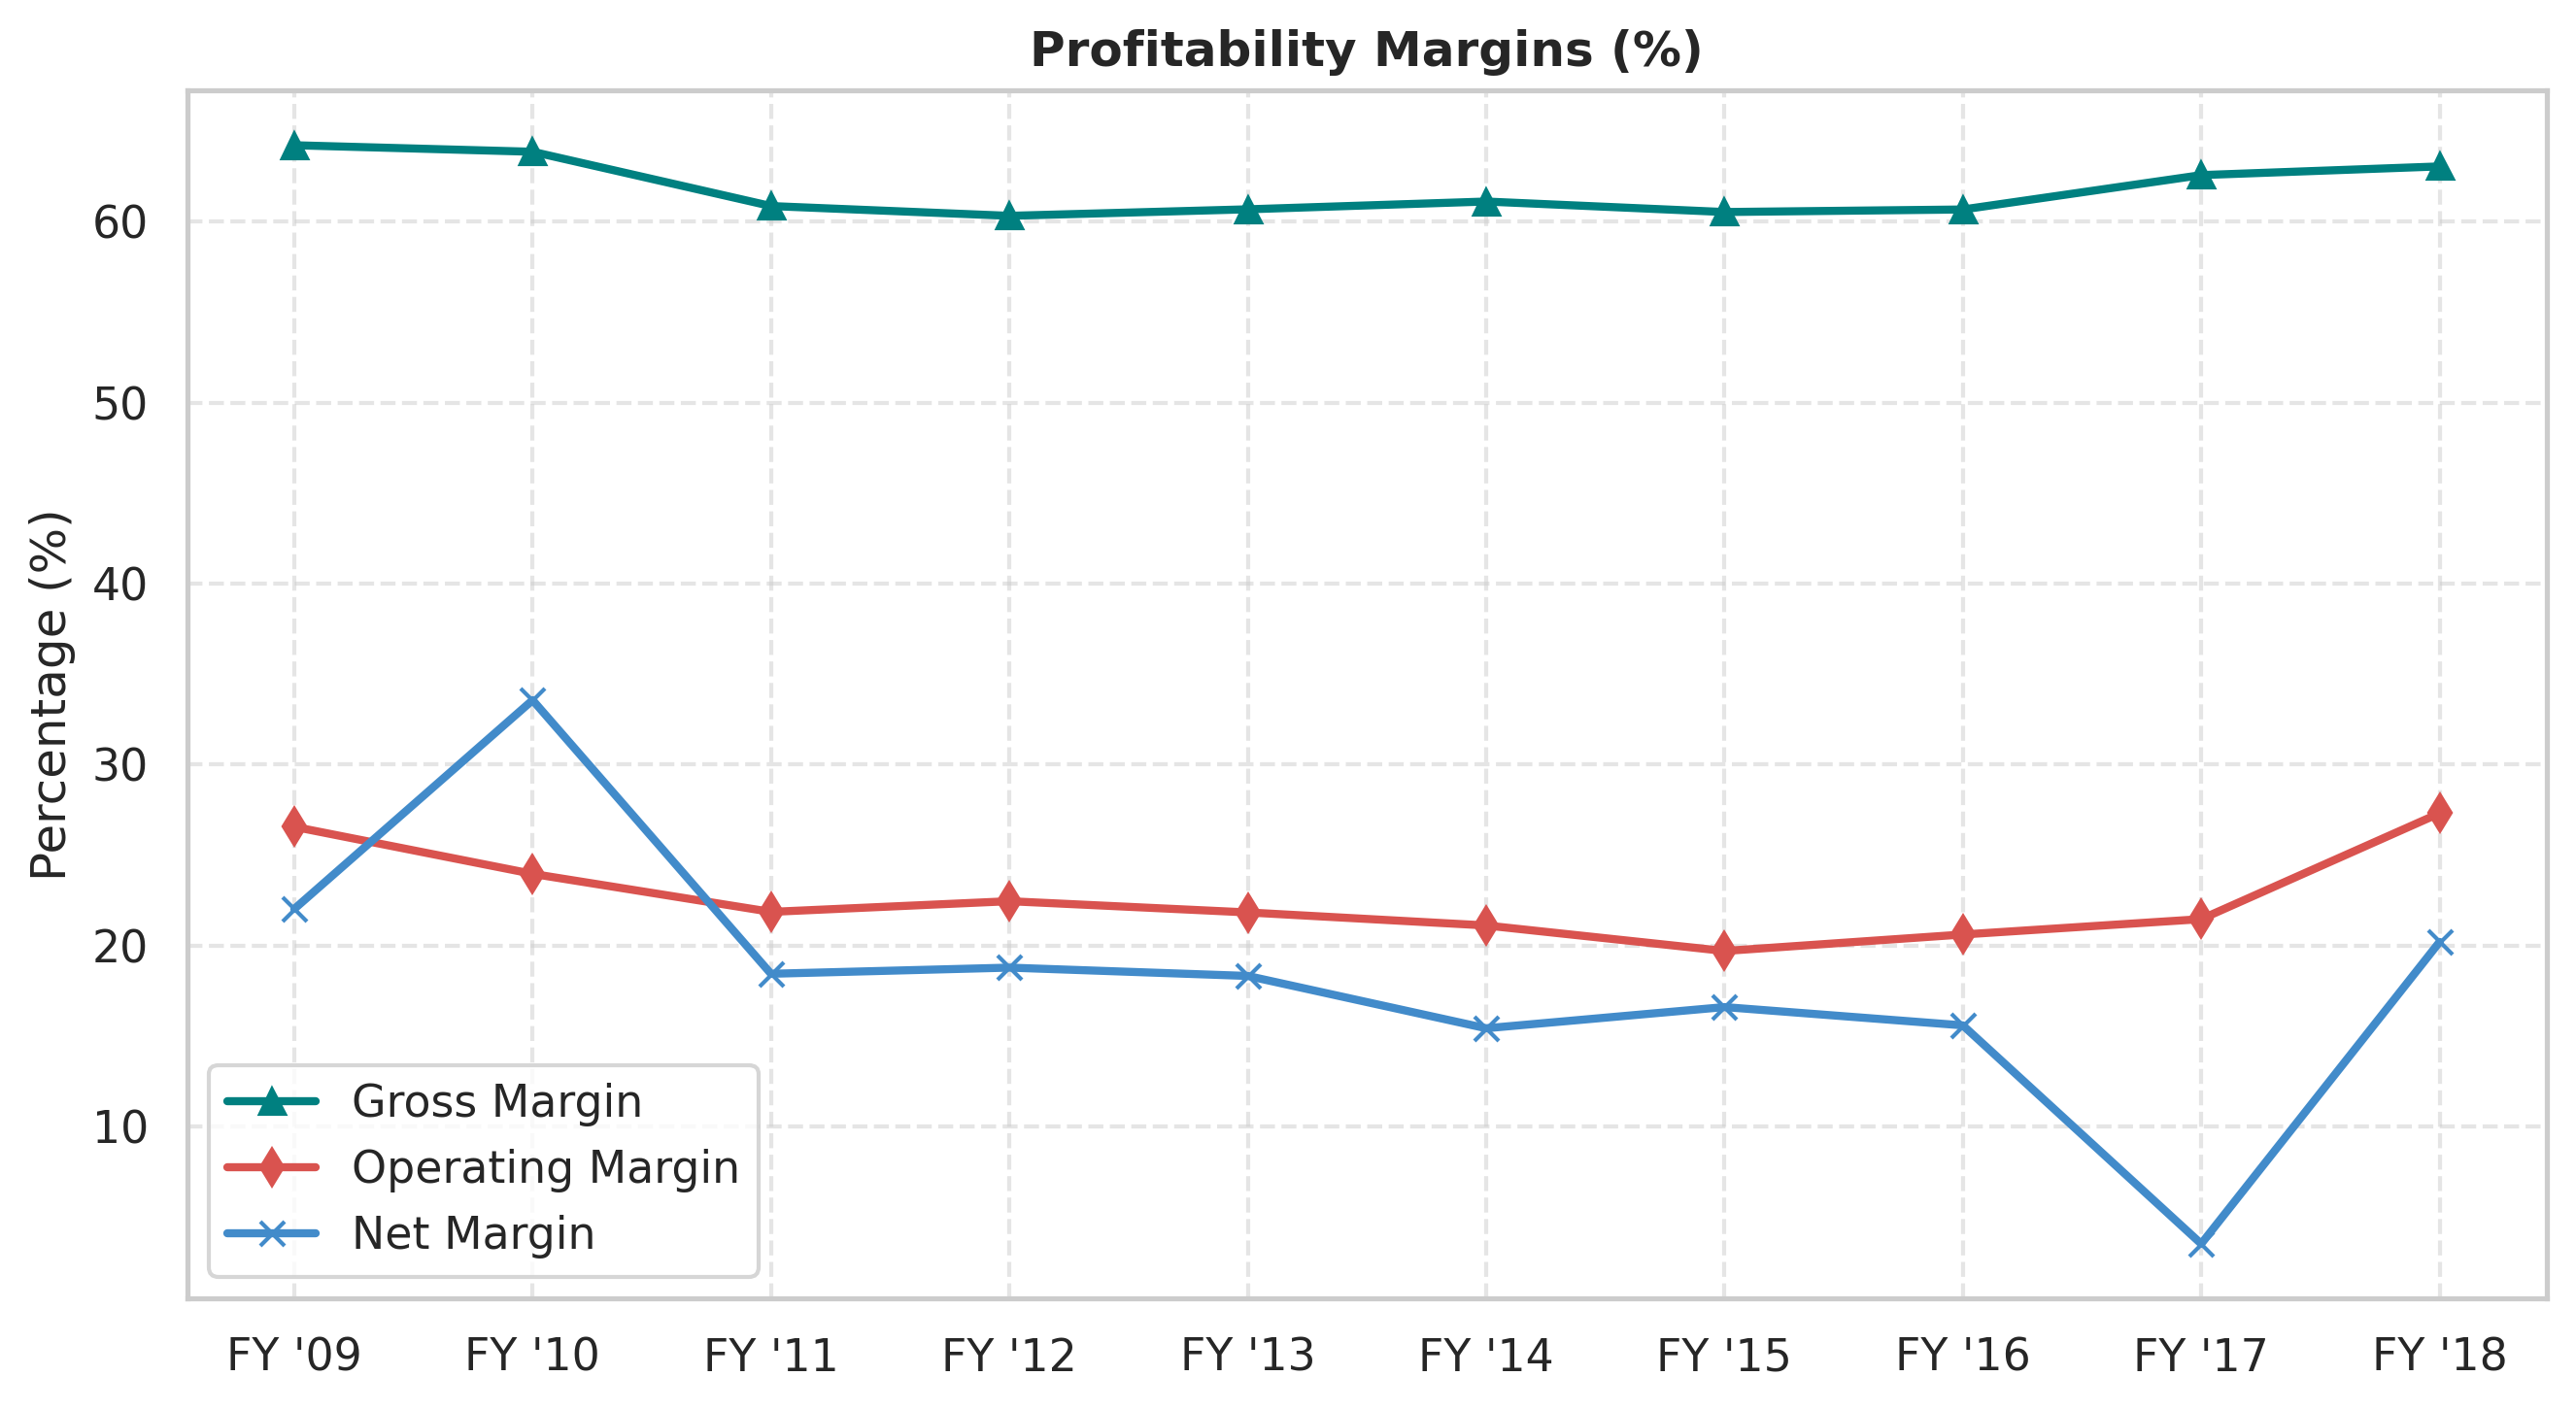

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(years, financial_summary['Gross Margin (%)'], marker='^', color='#008080', linewidth=2, label='Gross Margin')
plt.plot(years, financial_summary['Operating Margin (%)'], marker='d', color='#D9534F', linewidth=2, label='Operating Margin')
plt.plot(years, financial_summary['Net Margin (%)'], marker='x', color='#428BCA', linewidth=2, label='Net Margin')

plt.title('Profitability Margins (%)', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


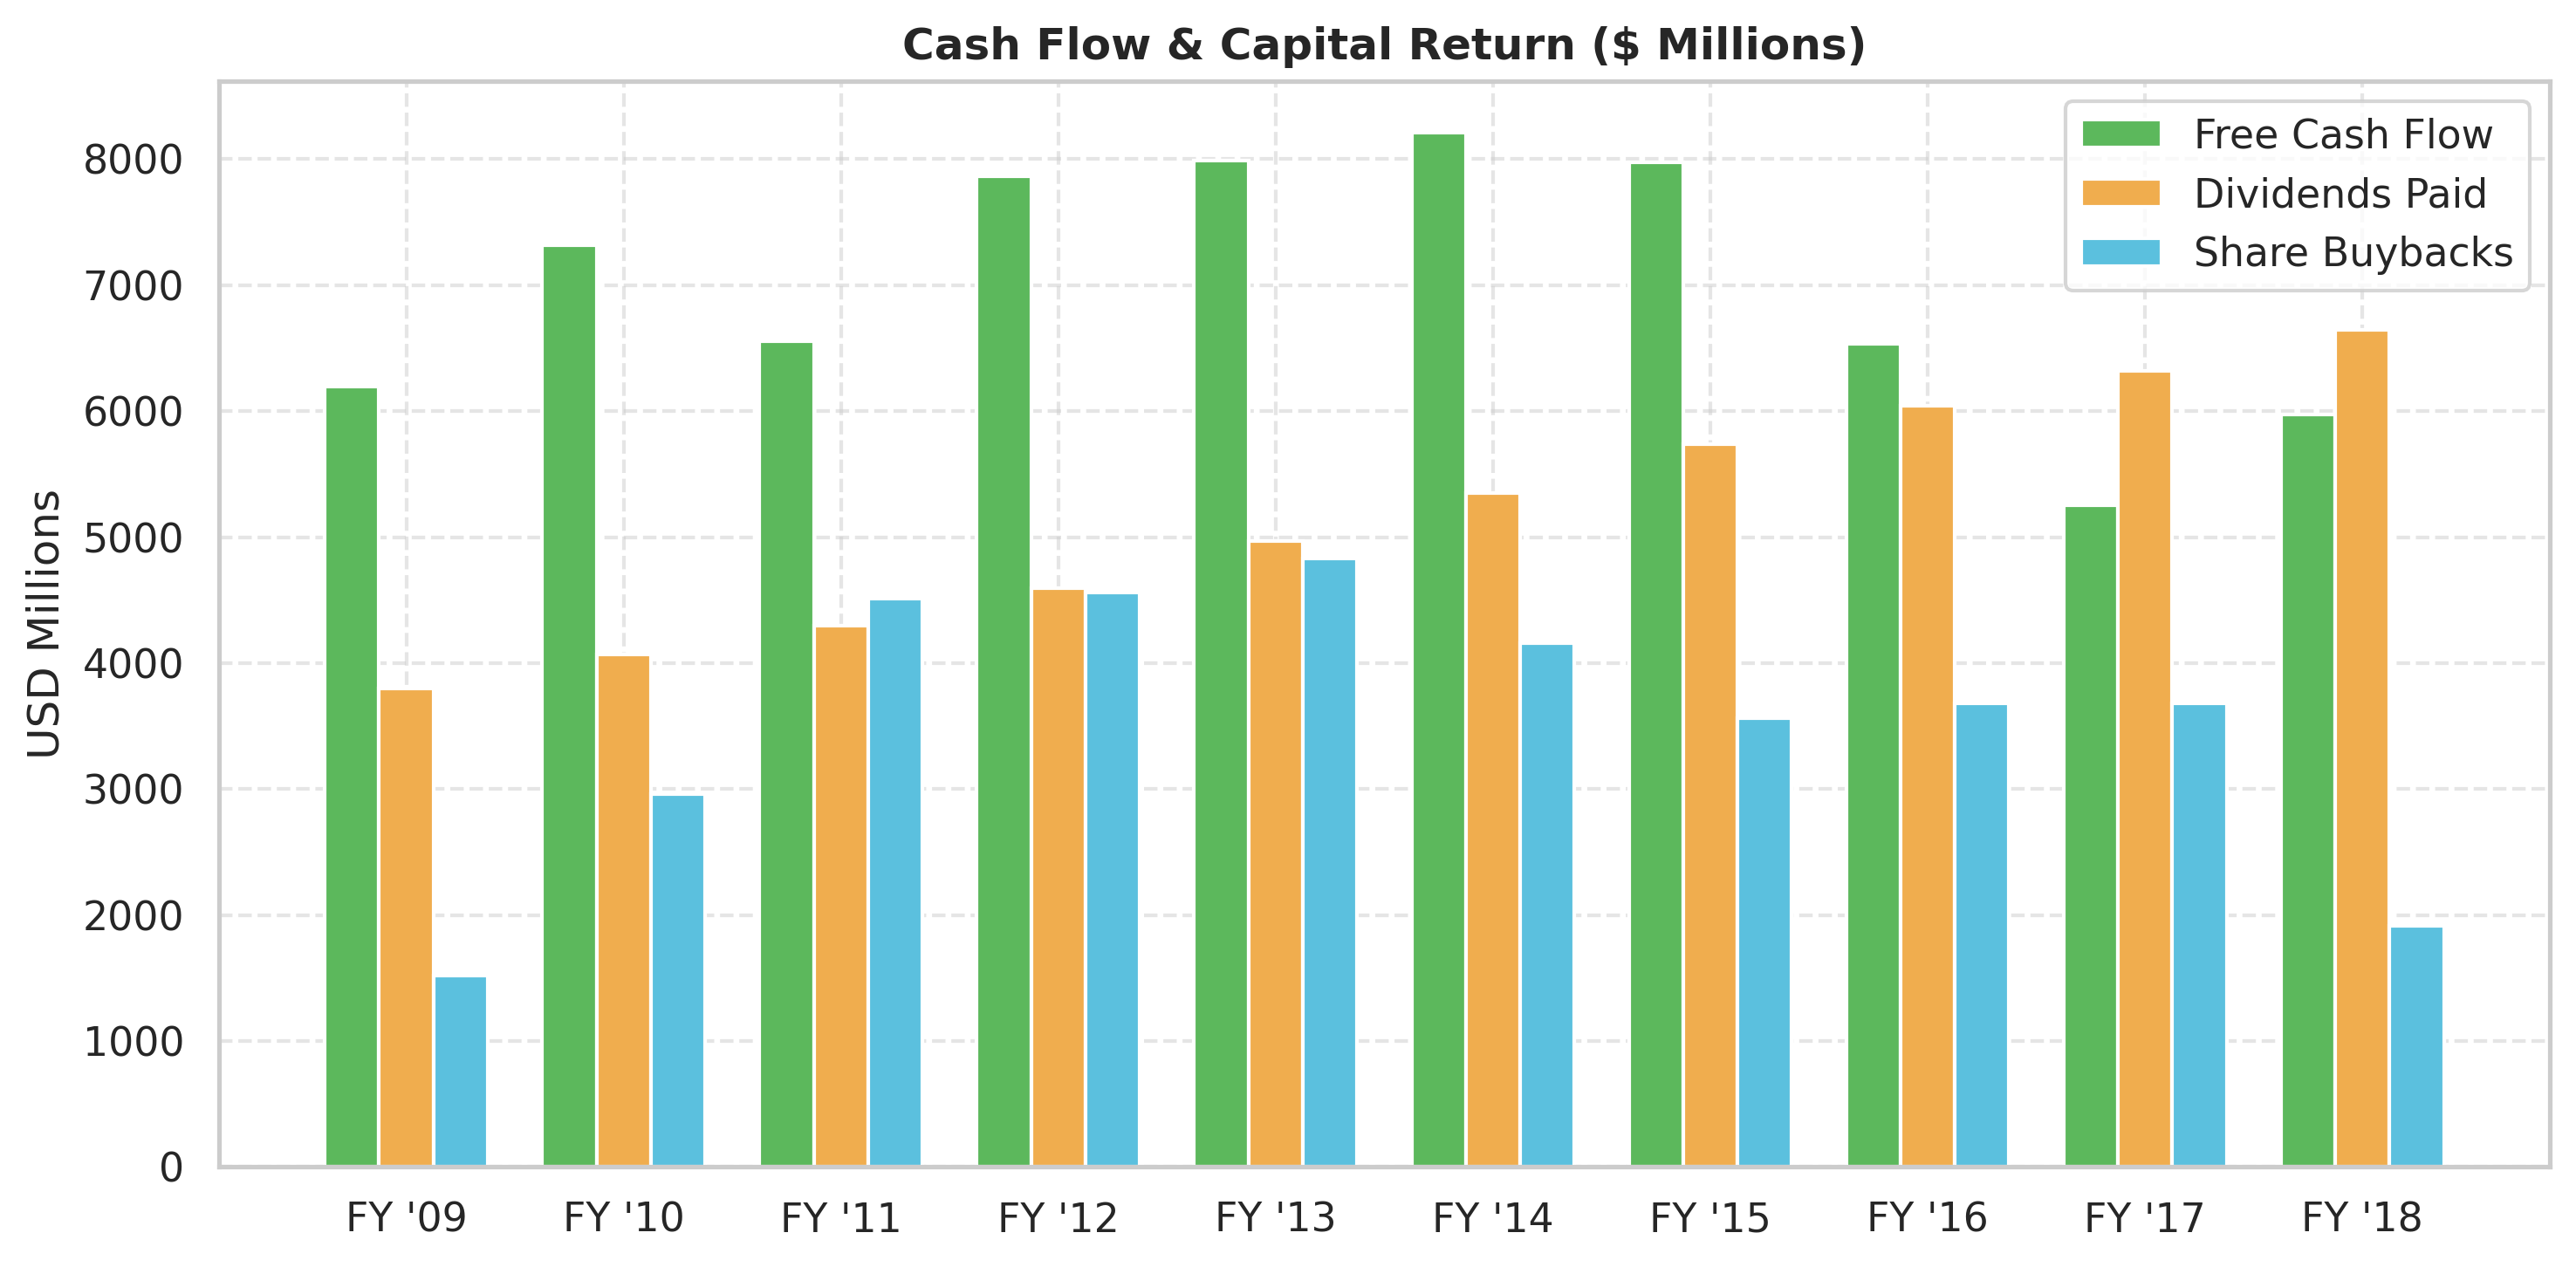

In [6]:
import numpy as np

x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, financial_summary['Free Cash Flow ($M)'], width, label='Free Cash Flow', color='#5CB85C')
plt.bar(x, financial_summary['Dividends Paid ($M)'], width, label='Dividends Paid', color='#F0AD4E')
plt.bar(x + width, financial_summary['Share Buybacks ($M)'], width, label='Share Buybacks', color='#5BC0DE')

plt.xticks(x, years)
plt.title('Cash Flow & Capital Return ($ Millions)', fontsize=12, fontweight='bold')
plt.ylabel('USD Millions')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


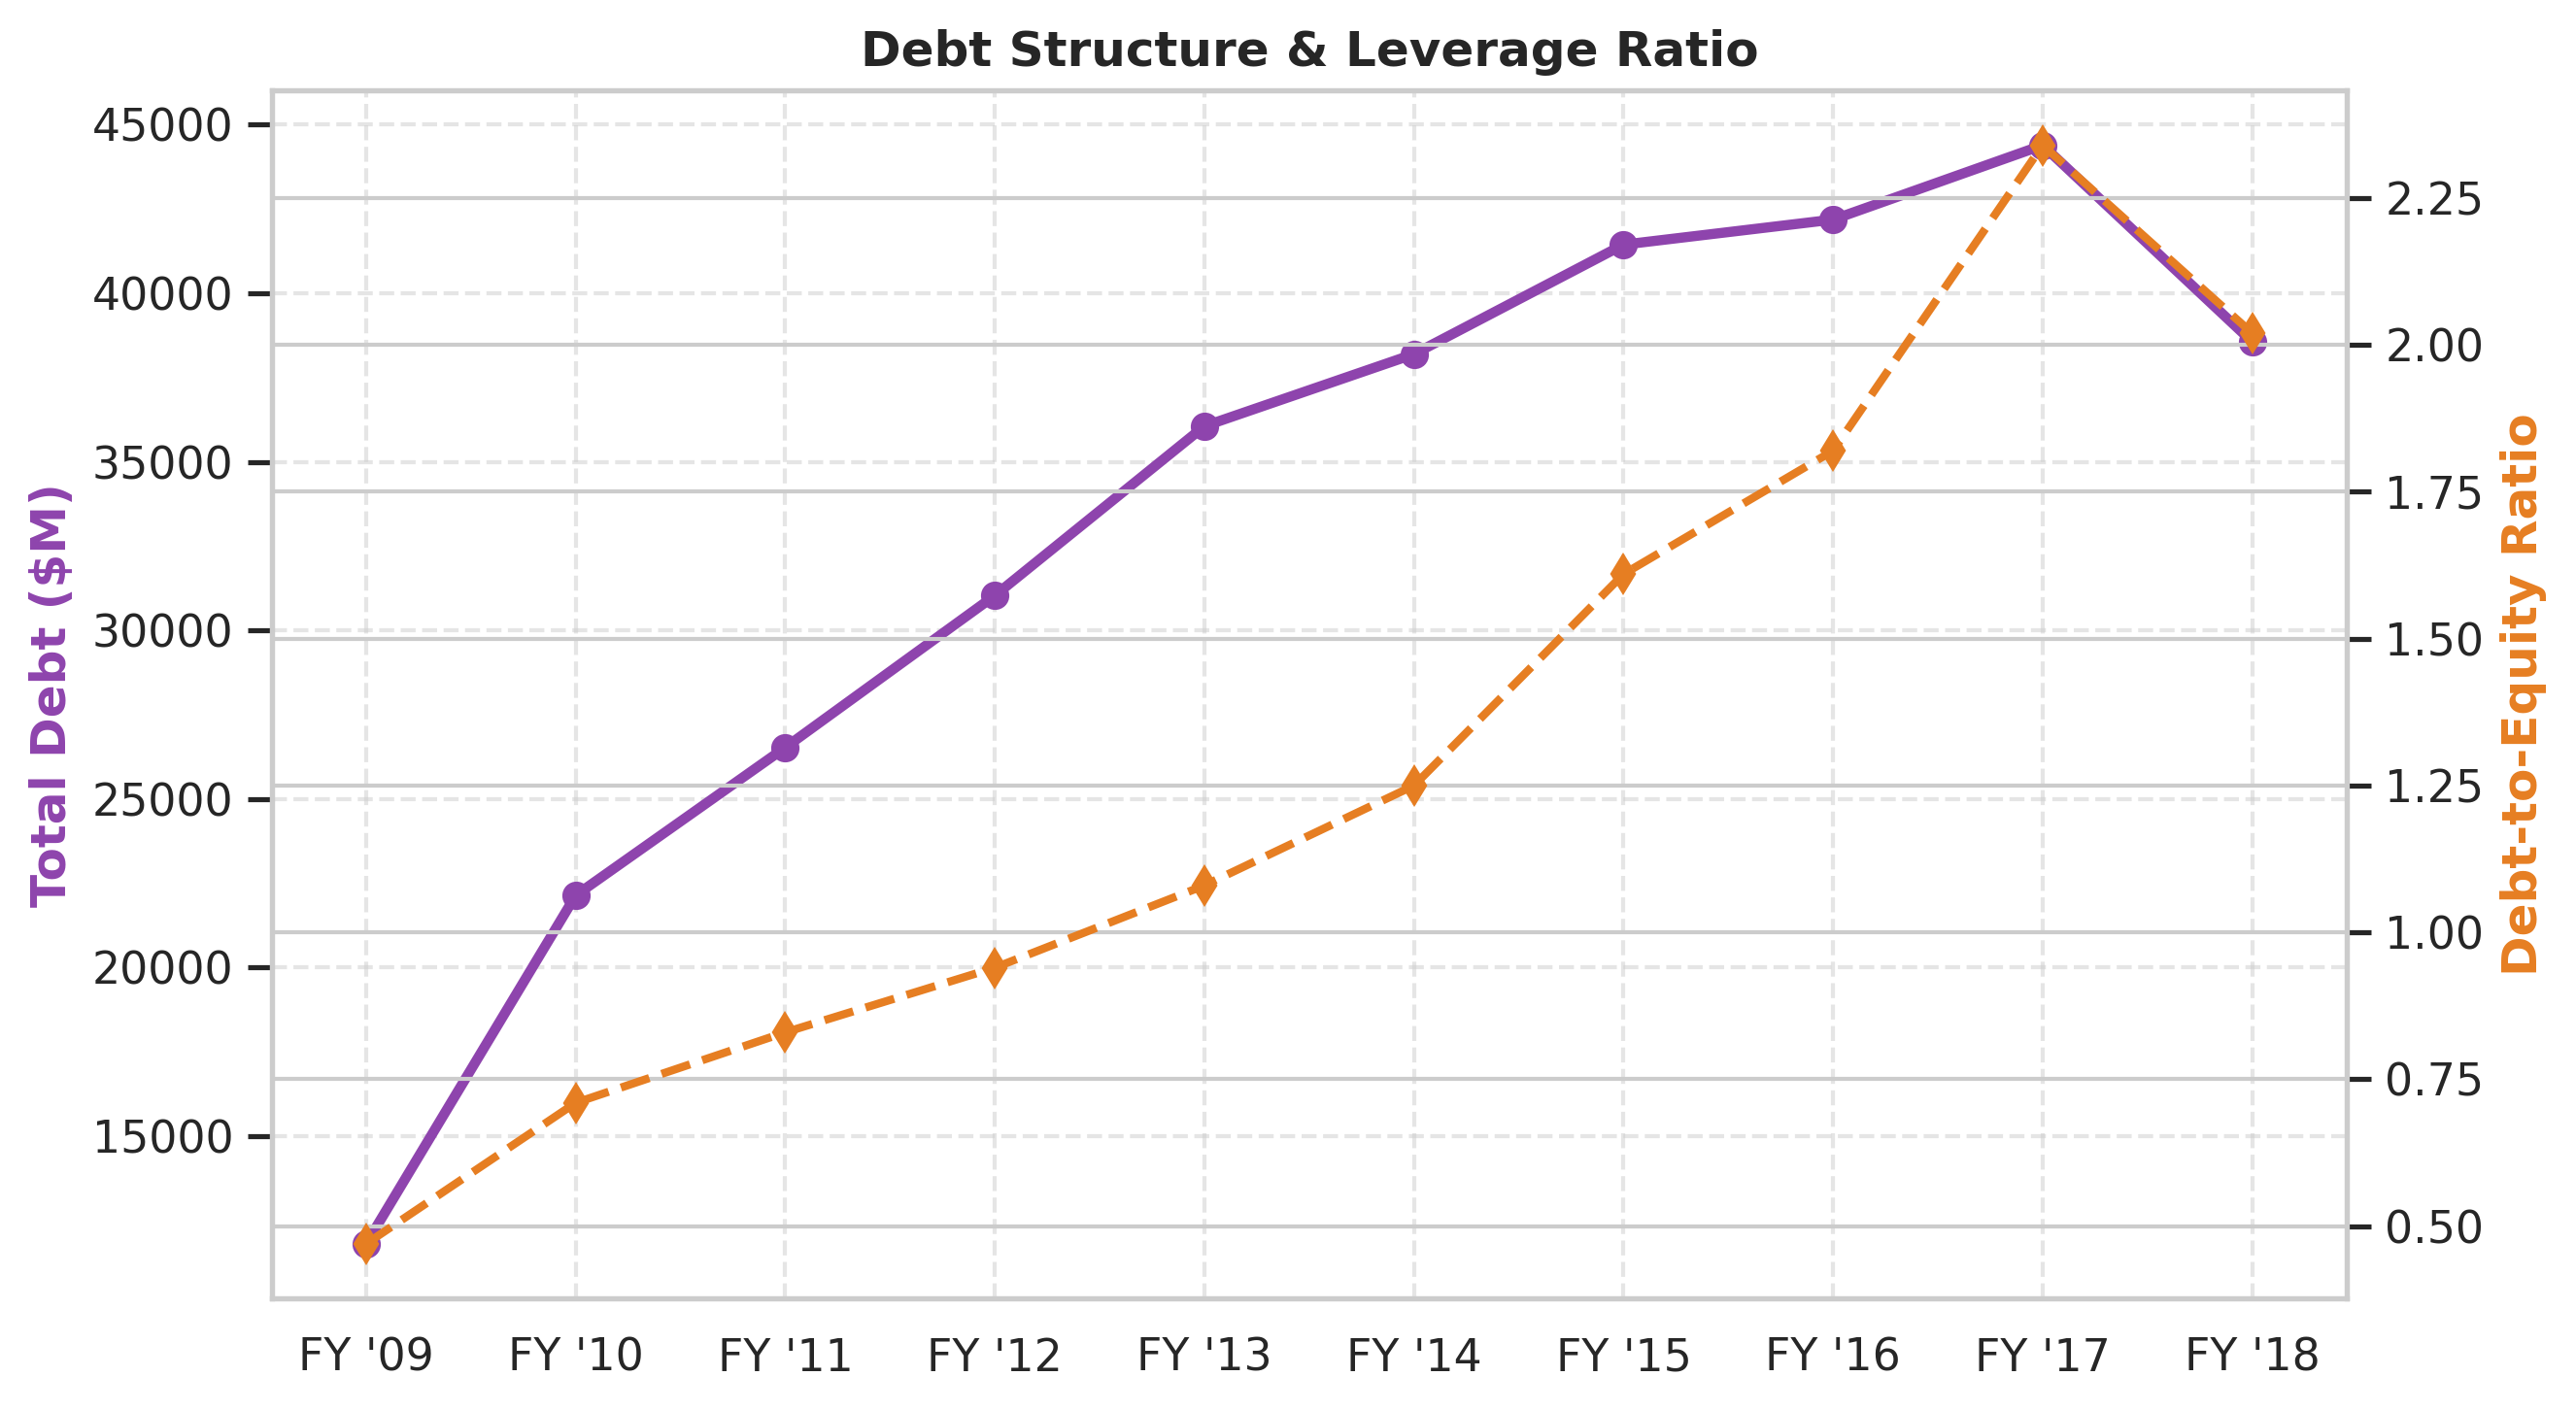

In [7]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(years, financial_summary['Total Debt ($M)'], marker='o', color='#8E44AD', linewidth=2.5, label='Total Debt ($M)')
ax1.set_ylabel('Total Debt ($M)', color='#8E44AD', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(years, financial_summary['Debt-to-Equity'], marker='d', color='#E67E22', linewidth=2, linestyle='--', label='Debt / Equity Ratio')
ax2.set_ylabel('Debt-to-Equity Ratio', color='#E67E22', fontweight='bold')

plt.title('Debt Structure & Leverage Ratio', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


This is Raw excel file 

In [8]:
import pandas as pd
import numpy as np

# Load raw excel file
df = pd.read_excel('Cola.xlsx')

# Locate statement boundaries
pnl_idx = df[df.iloc[:, 0] == 'Profit & Loss statement'].index[0]
bs_idx = df[df.iloc[:, 0] == 'Balance Sheet'].index[0]
cf_idx = df[df.iloc[:, 0] == 'Cash Flow statement'].index[0]

In [9]:
def extract_clean(df, start, end):
    sub = df.iloc[start:end].copy()
    headers = sub.iloc[1].values[2:]
    sub = sub.iloc[2:]
    sub.columns = ['Category', 'Line Item'] + list(headers)
    
    # Drop empty rows and strip leading/trailing spaces to prevent KeyError
    sub = sub.dropna(subset=['Line Item'])
    sub['Line Item'] = sub['Line Item'].astype(str).str.strip()
    sub = sub.drop_duplicates(subset=['Line Item'], keep='first').set_index('Line Item')
    
    years = [c for c in sub.columns if 'FY' in str(c)]
    sub[years] = sub[years].apply(pd.to_numeric, errors='coerce')
    return sub, years

pnl, years = extract_clean(df, pnl_idx, bs_idx)
bs, _ = extract_clean(df, bs_idx, cf_idx)
cf, _ = extract_clean(df, cf_idx, len(df))

## 5. DuPont Analysis (ROE Breakdown)

Full Clean Cell for DuPont Analysis

In [10]:
import numpy as np
import pandas as pd

# 1. Pull line items and force numeric types
revenue = pd.to_numeric(pnl.loc['NET OPERATING REVENUES', years])
net_income = pd.to_numeric(pnl.loc['NET INCOME ATTRIBUTABLE TO SHAREOWNERS OF THE COCA-COLA COMPANY', years])
total_assets = pd.to_numeric(bs.loc['Total assets', years])
total_equity = pd.to_numeric(bs.loc['Total equity', years])

# 2. Compute metrics
net_margin = (net_income / revenue) * 100
asset_turnover = revenue / total_assets
fin_leverage = total_assets / total_equity
roe = (net_income / total_equity) * 100

# 3. Build summary table with numpy round (works on all types)
dupont_df = pd.DataFrame({
    'Net Margin (%)': np.round(net_margin, 2),
    'Asset Turnover (x)': np.round(asset_turnover, 2),
    'Financial Leverage (x)': np.round(fin_leverage, 2),
    'ROE (%)': np.round(roe, 2)
})

dupont_df

,Net Margin (%),Asset Turnover (x),Financial Leverage (x),ROE (%)
FY '09,22.02,0.64,1.92,26.92
FY '10,33.56,0.48,2.33,37.64
FY '11,18.44,0.58,2.51,26.89
FY '12,18.78,0.56,2.60,27.19
FY '13,18.32,0.52,2.69,25.67
FY '14,15.43,0.50,3.01,23.23
FY '15,16.60,0.49,3.49,28.53
FY '16,15.59,0.48,3.76,28.11
FY '17,3.52,0.40,4.63,6.58
FY '18,20.20,0.38,4.37,33.76


# Summary

DuPont Analysis (ROE Drivers)
Return on Equity (ROE) maintained high levels (25%–34% across most years) primarily driven by financial leverage (1.92x to 4.37x) rather than asset turnover, directly reflecting the asset-light refranchising model.

Base FCF: $5,973.0M (FY '18)
Assumptions: 4.0% FCF growth rate, 7.5% WACC, 2.0% terminal growth
Implied Enterprise Value: $120.95 Billion (~77.6% anchored by terminal value)